In [ ]:
import zipfile
import os
import matplotlib.pyplot as plt

from natsort import natsorted

In [ ]:
# Define the path to the uploaded ZIP file
zip_file_path = '/content/dataset.zip'

# Define the directory where you want to extract the contents
extract_dir = '/content/data/'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Extract the ZIP file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f'Files extracted to {extract_dir}')

Files extracted to /content/data/


In [ ]:
len(os.listdir("/content/data/masks"))

3064

In [ ]:
len(os.listdir("/content/data/images"))

3064

In [ ]:
image_dir = "/content/data/images"
mask_dir = "/content/data/masks"

# Retrieve and naturally sort the filenames


print(image_files)
print(mask_files)

NameError: name 'image_files' is not defined

UNET Architecture

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Concatenate
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import MeanIoU
import cv2

In [ ]:
INPUT_SIZE = 256
data_path = "/content/data"

In [ ]:
def load_data(image_path,mask_path):
  images = []
  masks = []

  image_files = natsorted(os.listdir(image_path))
  mask_files = natsorted(os.listdir(mask_path))

  for img,mask in zip(image_files,mask_files):


    img = cv2.imread(os.path.join(image_path, img))
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    img = cv2.resize(img,(INPUT_SIZE,INPUT_SIZE))
    img = img/255.0

    mask = cv2.imread(os.path.join(mask_path, mask), cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask,(INPUT_SIZE,INPUT_SIZE))
    mask = mask/255.0

    images.append(img)
    masks.append(mask)

  # images = np.array(images)
  # masks = np.array(masks)
  return images,masks


images_path = "/content/data/images"
masks_path = "/content/data/masks"

# images,masks = load_data(images_path,masks_path)

In [ ]:
images = np.array(images)

In [ ]:
masks = np.array(masks)

In [ ]:
images.shape

(3064, 256, 256, 3)

In [ ]:
masks.shape

(24, 256, 256)

In [ ]:
ss

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(images,masks,test_size=0.2,random_state=42)

In [ ]:
import os
import cv2
import numpy as np
from natsort import natsorted

def data_generator(image_path, mask_path, batch_size):
    image_files = natsorted(os.listdir(image_path))
    mask_files = natsorted(os.listdir(mask_path))
    total_files = len(image_files)

    for i in range(0, total_files, batch_size):
        batch_images = []
        batch_masks = []
        batch_image_files = image_files[i:i + batch_size]
        batch_mask_files = mask_files[i:i + batch_size]

        for img_file, mask_file in zip(batch_image_files, batch_mask_files):
            img = cv2.imread(os.path.join(image_path, img_file))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (INPUT_SIZE, INPUT_SIZE))
            img = img / 255.0

            mask = cv2.imread(os.path.join(mask_path, mask_file), cv2.IMREAD_GRAYSCALE)
            mask = cv2.resize(mask, (INPUT_SIZE, INPUT_SIZE))
            mask = mask / 255.0

            batch_images.append(img)
            batch_masks.append(mask)

        yield np.array(batch_images), np.array(batch_masks)

# Usage example:
image_path = '/content/data/images'
mask_path = '/content/data/masks'
batch_size = 32  # Adjust based on your memory constraints

generator = data_generator(image_path, mask_path, batch_size)


In [ ]:
for images, masks in generator:
    print(images.shape)
    print(masks.shape)
    break
    pass

(32, 256, 256, 3)
(32, 256, 256)


data loader

In [ ]:
def load_image(image_path, mask_path, input_size):
    # Read and decode the image
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [input_size, input_size])
    image = tf.cast(image, tf.float32) / 255.0

    # Read and decode the mask
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, [input_size, input_size])
    mask = tf.cast(mask, tf.float32) / 255.0

    return image, mask

In [ ]:
def create_dataset(image_dir, mask_dir, input_size):
    image_paths = natsorted([os.path.join(image_dir, fname) for fname in os.listdir(image_dir) if fname.endswith('.png')])
    mask_paths = natsorted([os.path.join(mask_dir, fname) for fname in os.listdir(mask_dir) if fname.endswith('.png')])

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))
    dataset = dataset.map(lambda img, msk: load_image(img, msk, input_size),
                          num_parallel_calls=tf.data.experimental.AUTOTUNE)
    return dataset

In [ ]:
# create_dataset('/content/data/images','/content/data/masks',256)

In [ ]:
def split_dataset(dataset, train_size, val_size):
    train_dataset = dataset.take(train_size)
    val_dataset = dataset.skip(train_size).take(val_size)
    return train_dataset, val_dataset

In [ ]:
def prepare_for_training(dataset, batch_size):
    dataset = dataset.shuffle(buffer_size=1000)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
    return dataset

In [ ]:
    input_size = 256
    batch_size = 16

In [ ]:
image_dir = '/content/data/images'
mask_dir = '/content/data/masks'
dataset = create_dataset(image_dir, mask_dir, input_size)

In [ ]:
dataset_size = len(os.listdir(image_dir))
train_size = int(0.8 * dataset_size)
val_size = dataset_size - train_size

In [ ]:
train_dataset, val_dataset = split_dataset(dataset, train_size, val_size)


In [ ]:
train_dataset = prepare_for_training(train_dataset, batch_size)
val_dataset = prepare_for_training(val_dataset, batch_size)

In [ ]:
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, MaxPool2D, Conv2DTranspose, Concatenate, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [ ]:
def conv_block(inputs, num_filters):
    x = Conv2D(num_filters, 3, padding="same")(inputs)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Conv2D(num_filters, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    return x

def encoder_block(inputs, num_filters):
    x = conv_block(inputs, num_filters)
    p = MaxPool2D((2, 2))(x)
    return x, p

def decoder_block(inputs, skip_features, num_filters):
    x = Conv2DTranspose(num_filters, 2, strides=2, padding="same")(inputs)
    x = Concatenate()([x, skip_features])
    x = conv_block(x, num_filters)
    return x

def build_reduced_unet(input_shape):
    inputs = Input(input_shape)

    s1, p1 = encoder_block(inputs, 16)
    s2, p2 = encoder_block(p1, 32)
    s3, p3 = encoder_block(p2, 64)

    b1 = conv_block(p3, 512)

    d1 = decoder_block(b1, s3, 64)
    d2 = decoder_block(d1, s2, 32)
    d3 = decoder_block(d2, s1, 16)

    outputs = Conv2D(1, 1, padding="same", activation="sigmoid")(d3)

    model = Model(inputs, outputs, name="Reduced_UNET")
    model.compile(optimizer=Adam(learning_rate=0.0001), loss="binary_crossentropy", metrics=["accuracy"])

    return model

In [ ]:
input_shape = (256, 256, 3)
model = build_reduced_unet(input_shape)
model.summary()

Model: "Reduced_UNET"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 256, 256, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 256, 256, 16)   │            448 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 256, 256, 16)   │             64 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 256, 256, 16)   │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 256, 256, 16)   │          2,320 │ activation[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 256, 256, 16)   │             64 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 256, 256, 16)   │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 128, 128, 16)   │              0 │ activation_1[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 128, 128, 32)   │          4,640 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 128, 128, 32)   │            128 │ conv2d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_2 (Activation) │ (None, 128, 128, 32)   │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 128, 128, 32)   │          9,248 │ activation_2[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 128, 128, 32)   │            128 │ conv2d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_3 (Activation) │ (None, 128, 128, 32)   │              0 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 64, 64, 32)     │              0 │ activation_3[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 64, 64, 64)     │         18,496 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4

 Total params: 3,020,017 (11.52 MB)

 Trainable params: 3,017,073 (11.51 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [ ]:
# model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
)

Epoch 1/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 93s 368ms/step - accuracy: 0.8663 - loss: 0.4766 - val_accuracy: 0.9775 - val_loss: 0.4679
Epoch 2/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 43s 254ms/step - accuracy: 0.9805 - loss: 0.2718 - val_accuracy: 0.9784 - val_loss: 0.2863
Epoch 3/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 45s 256ms/step - accuracy: 0.9834 - loss: 0.2083 - val_accuracy: 0.9786 - val_loss: 0.2047
Epoch 4/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 86s 289ms/step - accuracy: 0.9868 - loss: 0.1817 - val_accuracy: 0.9783 - val_loss: 0.1915
Epoch 5/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 82s 288ms/step - accuracy: 0.9876 - loss: 0.1663 - val_accuracy: 0.9793 - val_loss: 0.1657
Epoch 6/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 44s 254ms/step - accuracy: 0.9881 - loss: 0.1481 - val_accuracy: 0.9785 - val_loss: 0.1556
Epoch 7/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 81s 252ms/step - accuracy: 0.9899 - loss: 0.1308 - val_accuracy: 0.9704 - val_loss: 0.1573
Epoch 8/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 46s 263ms/step - accuracy: 0.9888 - loss: 0

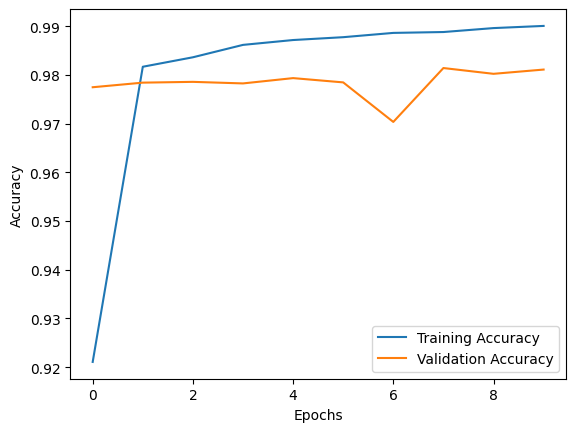

In [ ]:
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

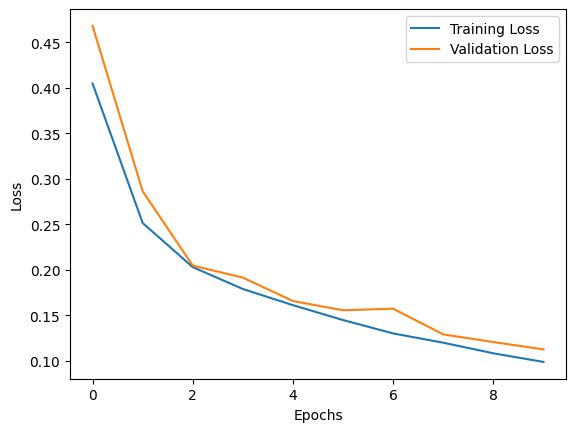

In [ ]:
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
threshold mask
(256, 256, 1)


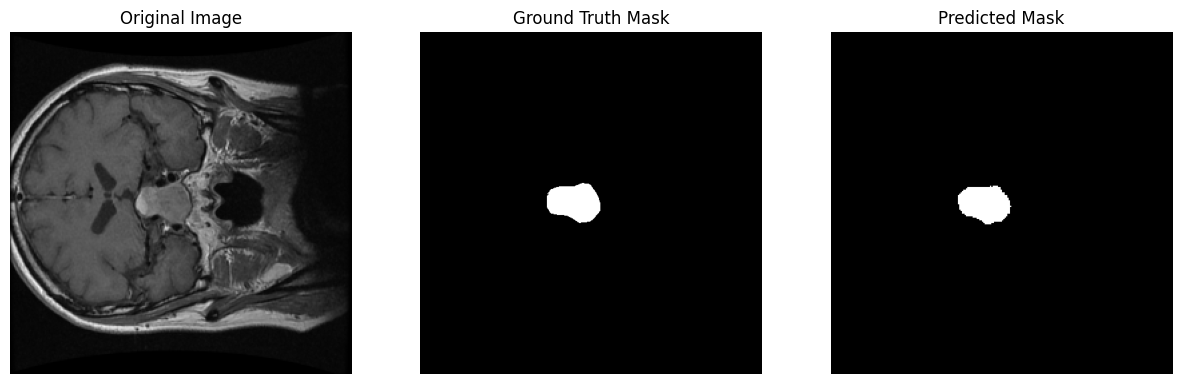

In [ ]:
image_path = "/content/data/images/1500.png"
mask_path = "/content/data/masks/1500_mask.png"  # Optional, if you have ground truth

# Load the image
image = tf.io.read_file(image_path)
image = tf.image.decode_png(image, channels=3)
image = tf.image.resize(image, [256, 256])
image = tf.cast(image, tf.float32) / 255.0
# image = tf.io.read_file(image_path)
# image = tf.image.decode_jpeg(image, channels=3)  # Adjust channels as needed
# image = tf.image.convert_image_dtype(image, tf.float32)

mask = tf.io.read_file(mask_path)
mask = tf.image.decode_jpeg(mask, channels=1)  # Adjust channels as needed
mask = tf.image.convert_image_dtype(mask, tf.float32)
# Apply any preprocessing that your model expects

# Add batch dimension
input_image = tf.expand_dims(image, 0)

# Get prediction
prediction = model.predict(input_image)
predicted_mask = prediction[0]

pm = np.array(predicted_mask)
    # Threshold the mask
thresholded_mask = (pm > 0.5).astype(np.uint8)

print("threshold mask")
print(thresholded_mask.shape)
# Display the result
# plt.figure(figsize=(8, 4))

# plt.subplot(1, 2, 1)
# plt.title("Image")
# plt.imshow(image.numpy())

# plt.subplot(1, 2, 2)
# plt.title("Predicted Mask")
# plt.imshow(predicted_mask.squeeze(), cmap='gray')
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(image.numpy(), cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Ground Truth Mask")
plt.imshow(mask.numpy(), cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Predicted Mask")
plt.imshow(thresholded_mask.squeeze(), cmap='gray')
plt.axis('off')

plt.show()

In [ ]:
model.save('unet_seg.h5')

In [ ]:
from tensorflow.keras.models import load_model
m5 = load_model("unet_seg.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
threshold mask
(256, 256, 1)


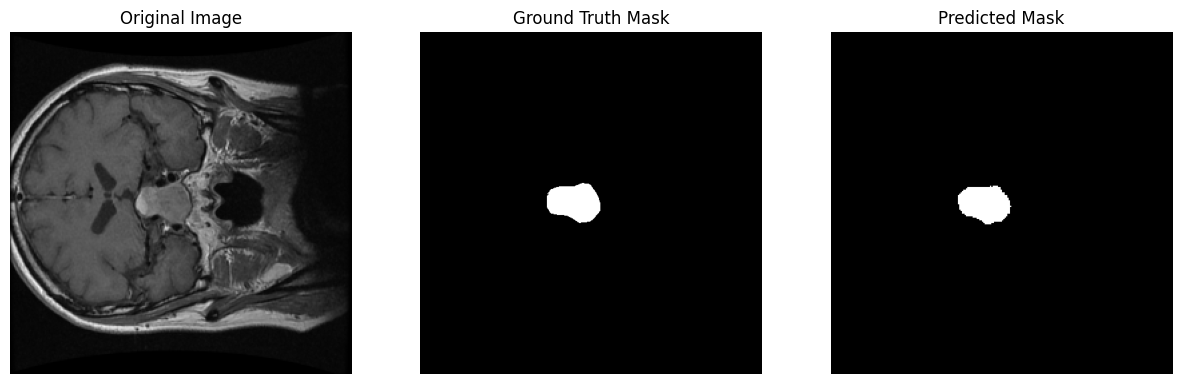

In [ ]:
image_path = "/content/data/images/1500.png"
mask_path = "/content/data/masks/1500_mask.png"  # Optional, if you have ground truth

# Load the image
image = tf.io.read_file(image_path)
image = tf.image.decode_png(image, channels=3)
image = tf.image.resize(image, [256, 256])
image = tf.cast(image, tf.float32) / 255.0
# image = tf.io.read_file(image_path)
# image = tf.image.decode_jpeg(image, channels=3)  # Adjust channels as needed
# image = tf.image.convert_image_dtype(image, tf.float32)

mask = tf.io.read_file(mask_path)
mask = tf.image.decode_jpeg(mask, channels=1)  # Adjust channels as needed
mask = tf.image.convert_image_dtype(mask, tf.float32)
# Apply any preprocessing that your model expects

# Add batch dimension
input_image = tf.expand_dims(image, 0)

# Get prediction
prediction = m5.predict(input_image)
predicted_mask = prediction[0]

pm = np.array(predicted_mask)
    # Threshold the mask
thresholded_mask = (pm > 0.5).astype(np.uint8)

print("threshold mask")
print(thresholded_mask.shape)
# Display the result
# plt.figure(figsize=(8, 4))

# plt.subplot(1, 2, 1)
# plt.title("Image")
# plt.imshow(image.numpy())

# plt.subplot(1, 2, 2)
# plt.title("Predicted Mask")
# plt.imshow(predicted_mask.squeeze(), cmap='gray')
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(image.numpy(), cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Ground Truth Mask")
plt.imshow(mask.numpy(), cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Predicted Mask")
plt.imshow(thresholded_mask.squeeze(), cmap='gray')
plt.axis('off')

plt.show()